# Predykcja anulowania rezerwacji hotelowych — wersja podstawowa (baseline)

**Projekt zaliczeniowy ASI** · Jastrzębski, Ruczyński

## Problem
Hotele tracą przychód i moce przerobowe przez rezerwacje, które zostają **anulowane**.
Gdyby dało się je przewidzieć *w momencie rezerwacji*, hotel mógłby reagować
(overbooking, depozyty, oferty), zmniejszając straty. Budujemy model
**klasyfikacji binarnej**, który przewiduje, czy dana rezerwacja zostanie anulowana.

## Dane
Zbiór **Hotel Booking Demand** (`hotel-booking-demand`, Antonio et al. 2019) —
realne rezerwacje dwóch portugalskich hoteli (miejski i resort) z lat **2015–2017**.

- **119 390** rezerwacji, **32** kolumny
- Zmienna celu: **`is_canceled`** (1 = anulowana, 0 = zrealizowana)
- Klasy: ok. **37%** anulowanych / 63% zrealizowanych (umiarkowanie zbalansowane)

## Zakres tego notebooka (wymaganie: *wersja podstawowa modelu*)
1. Eksploracja danych (EDA)
2. Preprocessing
3. Trening modelu bazowego
4. Ewaluacja

> Refaktoryzacja do pipeline'u Kedro, śledzenie eksperymentów (MLflow), strojenie
> (Optuna), AutoML, wdrożenie (FastAPI + Prometheus + Docker) i MLOps (DVC + Model
> Registry) realizowane są w kolejnych etapach projektu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay,
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
pd.set_option("display.max_columns", 40)

## 1. Wczytanie danych
Dane trzymamy w `data/01_raw/` (konwencja warstw Kedro). Jeśli pliku nie ma,
pobiera go skrypt `scripts/fetch_data.py` z publicznego mirrora (TidyTuesday).

In [2]:
from pathlib import Path

RAW = Path("../data/01_raw/hotel_bookings.csv")
if not RAW.exists():  # awaryjne pobranie
    url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-02-11/hotels.csv"
    pd.read_csv(url).to_csv(RAW, index=False)

df = pd.read_csv(RAW)
print(f"Wymiary: {df.shape[0]:,} wierszy × {df.shape[1]} kolumn")
df.head()

Wymiary: 119,390 wierszy × 32 kolumn


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Typy kolumn i kompletność
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
# Statystyki kolumn numerycznych
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.37,0.48,0.00,0.00,0.00,1.0,1.0
lead_time,119390.0,104.01,106.86,0.00,18.00,69.00,160.0,737.0
arrival_date_year,119390.0,2016.16,0.71,2015.00,2016.00,2016.00,2017.0,2017.0
arrival_date_week_number,119390.0,27.17,13.61,1.00,16.00,28.00,38.0,53.0
arrival_date_day_of_month,119390.0,15.80,8.78,1.00,8.00,16.00,23.0,31.0
stays_in_weekend_nights,119390.0,0.93,1.00,0.00,0.00,1.00,2.0,19.0
stays_in_week_nights,119390.0,2.50,1.91,0.00,1.00,2.00,3.0,50.0
adults,119390.0,1.86,0.58,0.00,2.00,2.00,2.0,55.0
children,119386.0,0.10,0.40,0.00,0.00,0.00,0.0,10.0
babies,119390.0,0.01,0.10,0.00,0.00,0.00,0.0,10.0


## 2. Eksploracja danych (EDA)

### 2.1 Rozkład zmiennej celu
Sprawdzamy proporcję klas — od tego zależy m.in. dobór metryki (sama *accuracy*
przy niezbalansowanych klasach bywa myląca, dlatego raportujemy też **F1** i **ROC-AUC**).

Liczność klas:
 is_canceled
0    75166
1    44224

Proporcje:
 is_canceled
0    0.63
1    0.37


C:\Users\PJATK\AppData\Local\Temp\ipykernel_6244\4011356257.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["0 — zrealizowana", "1 — anulowana"])


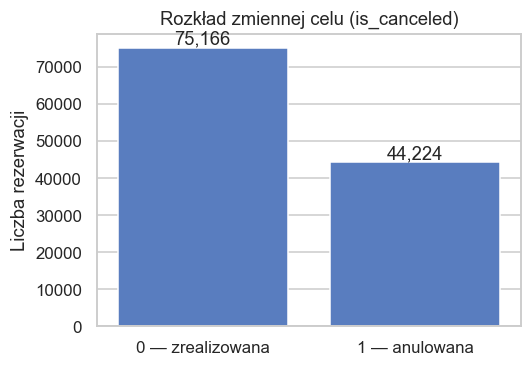

In [5]:
counts = df["is_canceled"].value_counts().sort_index()
rates = df["is_canceled"].value_counts(normalize=True).sort_index()
print("Liczność klas:\n", counts.to_string())
print("\nProporcje:\n", rates.round(3).to_string())

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(data=df, x="is_canceled", ax=ax)
ax.set_xticklabels(["0 — zrealizowana", "1 — anulowana"])
ax.set_title("Rozkład zmiennej celu (is_canceled)")
ax.set_xlabel(""); ax.set_ylabel("Liczba rezerwacji")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.tight_layout(); plt.show()

### 2.2 Braki danych
Kilka kolumn ma braki. Najważniejszy wniosek: **`company`** jest puste w ~94%
przypadków (do usunięcia), a `agent`/`country`/`children` uzupełnimy.

Odsetek braków [%]:
 company    94.31
agent      13.69
country     0.41


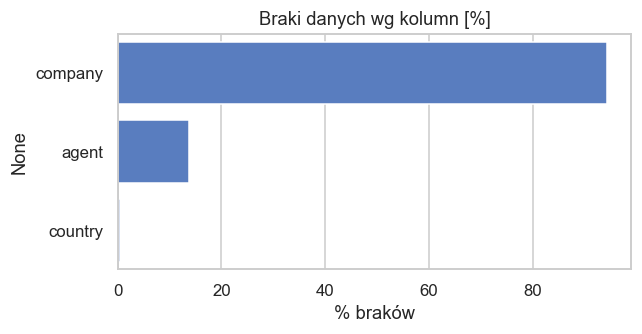

In [6]:
miss = (df.isnull().mean() * 100).round(2)
miss = miss[miss > 0].sort_values(ascending=False)
print("Odsetek braków [%]:\n", miss.to_string())

fig, ax = plt.subplots(figsize=(6, 3.2))
sns.barplot(x=miss.values, y=miss.index, ax=ax)
ax.set_title("Braki danych wg kolumn [%]"); ax.set_xlabel("% braków")
plt.tight_layout(); plt.show()

### 2.3 Co napędza anulowania?
Patrzymy na **wskaźnik anulowań** w przekroju kilku zmiennych oraz na rozkład
`lead_time` (liczba dni między rezerwacją a przyjazdem).

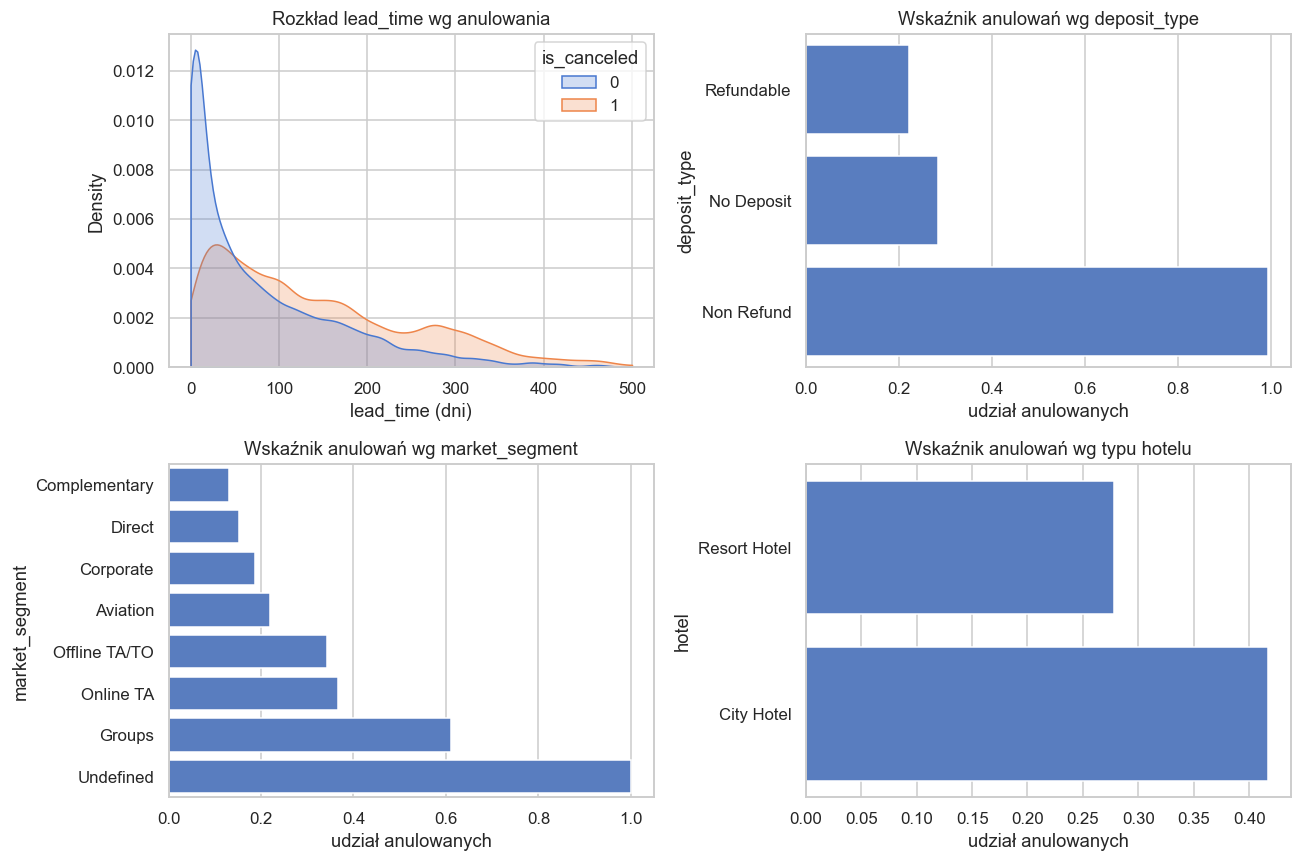

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# lead_time vs anulowanie
sns.kdeplot(data=df, x="lead_time", hue="is_canceled", common_norm=False,
            fill=True, ax=axes[0, 0], clip=(0, 500))
axes[0, 0].set_title("Rozkład lead_time wg anulowania")
axes[0, 0].set_xlabel("lead_time (dni)")

# wskaźnik anulowań wg typu depozytu
dep = df.groupby("deposit_type")["is_canceled"].mean().sort_values()
sns.barplot(x=dep.values, y=dep.index, ax=axes[0, 1])
axes[0, 1].set_title("Wskaźnik anulowań wg deposit_type")
axes[0, 1].set_xlabel("udział anulowanych")

# wskaźnik anulowań wg segmentu rynku
seg = df.groupby("market_segment")["is_canceled"].mean().sort_values()
sns.barplot(x=seg.values, y=seg.index, ax=axes[1, 0])
axes[1, 0].set_title("Wskaźnik anulowań wg market_segment")
axes[1, 0].set_xlabel("udział anulowanych")

# wskaźnik anulowań wg typu hotelu
hot = df.groupby("hotel")["is_canceled"].mean().sort_values()
sns.barplot(x=hot.values, y=hot.index, ax=axes[1, 1])
axes[1, 1].set_title("Wskaźnik anulowań wg typu hotelu")
axes[1, 1].set_xlabel("udział anulowanych")

plt.tight_layout(); plt.show()

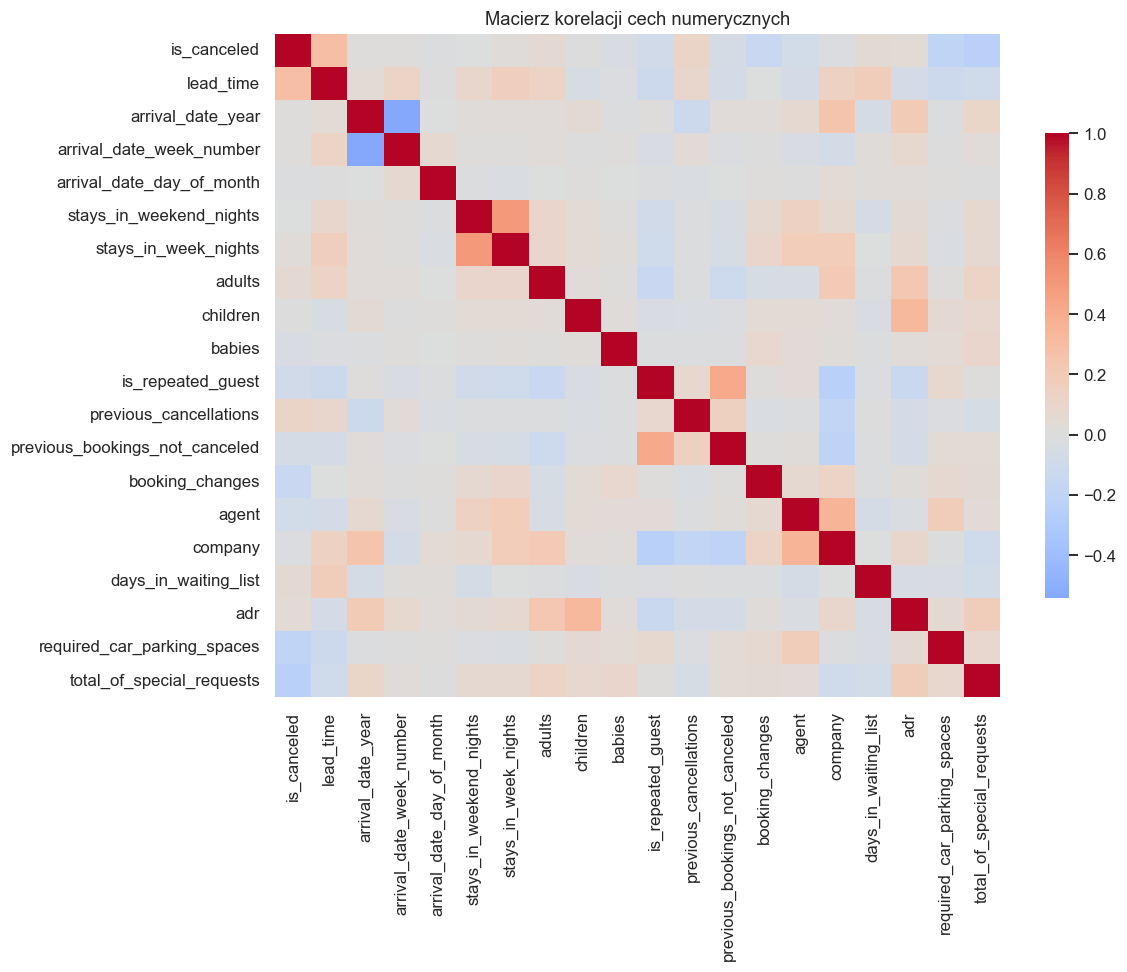

Najsilniej skorelowane z is_canceled:
lead_time                      0.293
total_of_special_requests      0.235
required_car_parking_spaces    0.195
booking_changes                0.144
previous_cancellations         0.110
is_repeated_guest              0.085
agent                          0.083
adults                         0.060


In [8]:
# Korelacje cech numerycznych ze zmienną celu
num = df.select_dtypes("number")
corr = num.corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax,
            cbar_kws={"shrink": 0.7})
ax.set_title("Macierz korelacji cech numerycznych")
plt.tight_layout(); plt.show()

print("Najsilniej skorelowane z is_canceled:")
print(corr["is_canceled"].drop("is_canceled").abs().sort_values(ascending=False).head(8).round(3).to_string())

## 3. Preprocessing

### ⚠️ Uwaga: wyciek informacji (data leakage)
Kolumny **`reservation_status`** i **`reservation_status_date`** opisują *wynik*
rezerwacji (np. `Canceled` / `Check-Out` / `No-Show`) — są znane dopiero **po**
fakcie. Zostawienie ich dałoby ~100% trafności w treningu, ale model byłby
bezużyteczny w praktyce. **Usuwamy je.**

Pozostałe decyzje:
- usuwamy `company` (~94% braków),
- na potrzeby baseline upraszczamy też wysokokardynalne `country`/`agent`
  (pełne kodowanie przeniesiemy do pipeline'u Kedro w kolejnym etapie),
- braki `children` → 0,
- zmienne kategoryczne kodujemy **one-hot** (`pd.get_dummies`).

In [9]:
LEAKAGE = ["reservation_status", "reservation_status_date"]
DROP_BASELINE = LEAKAGE + ["company", "country", "agent"]

data = df.copy()
data["children"] = data["children"].fillna(0)

y = data["is_canceled"]
X = data.drop(columns=["is_canceled"] + DROP_BASELINE)

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print(f"Kolumny kategoryczne do zakodowania ({len(cat_cols)}): {cat_cols}")

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"Macierz cech po kodowaniu: {X.shape[0]:,} × {X.shape[1]}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

Kolumny kategoryczne do zakodowania (9): ['hotel', 'arrival_date_month', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
Macierz cech po kodowaniu: 119,390 × 69


Train: 95,512 | Test: 23,878


## 4. Model bazowy
Jako baseline wybieramy **Random Forest** — odporny, dobrze radzi sobie z mieszanką
cech numerycznych i kategorycznych, nie wymaga skalowania i daje sensowny punkt
odniesienia bez strojenia.

In [10]:
model = RandomForestClassifier(
    n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1
)
model.fit(X_train, y_train)
print("Model wytrenowany.")

Model wytrenowany.


## 5. Ewaluacja
Raportujemy **accuracy**, **F1** i **ROC-AUC**, a do tego macierz pomyłek i krzywą ROC.

In [11]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {auc:.3f}\n")
print(classification_report(y_test, y_pred, target_names=["zrealizowana", "anulowana"]))

Accuracy : 0.869
F1-score : 0.811
ROC-AUC  : 0.933

              precision    recall  f1-score   support

zrealizowana       0.87      0.93      0.90     15033
   anulowana       0.87      0.76      0.81      8845

    accuracy                           0.87     23878
   macro avg       0.87      0.85      0.86     23878
weighted avg       0.87      0.87      0.87     23878



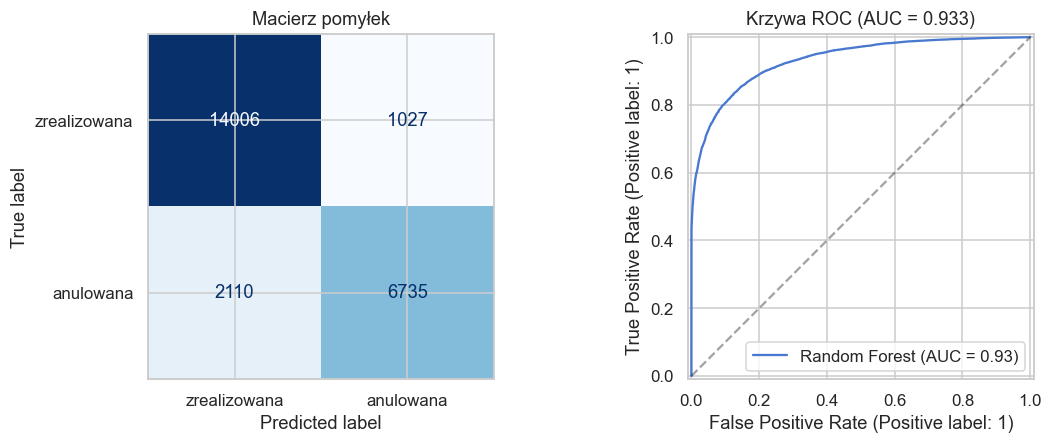

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["zrealizowana", "anulowana"],
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Macierz pomyłek")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name="Random Forest")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title(f"Krzywa ROC (AUC = {auc:.3f})")
plt.tight_layout(); plt.show()

## 6. Ważność cech
Które zmienne model uznaje za najważniejsze? To wstępna intuicja, którą rozwiniemy
w etapie inżynierii cech.

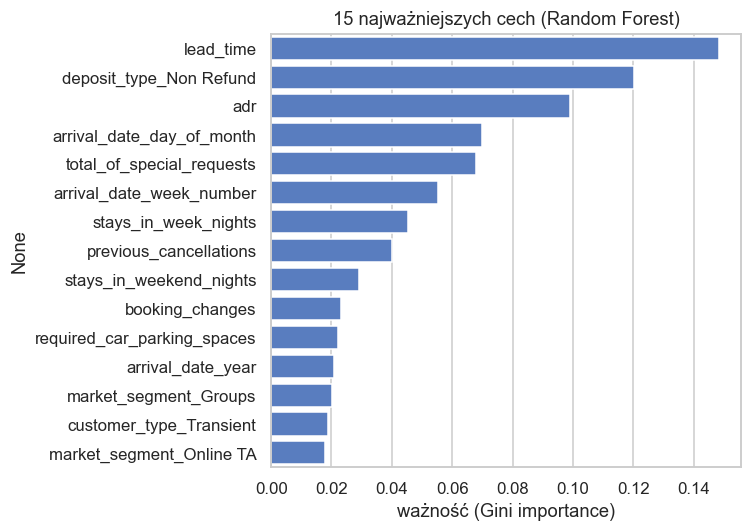

lead_time                      0.148
deposit_type_Non Refund        0.120
adr                            0.099
arrival_date_day_of_month      0.070
total_of_special_requests      0.068
arrival_date_week_number       0.055
stays_in_week_nights           0.045
previous_cancellations         0.040
stays_in_weekend_nights        0.029
booking_changes                0.023
required_car_parking_spaces    0.022
arrival_date_year              0.021
market_segment_Groups          0.020
customer_type_Transient        0.019
market_segment_Online TA       0.018
dtype: float64

In [13]:
imp = (pd.Series(model.feature_importances_, index=X.columns)
       .sort_values(ascending=False).head(15))
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=imp.values, y=imp.index, ax=ax)
ax.set_title("15 najważniejszych cech (Random Forest)")
ax.set_xlabel("ważność (Gini importance)")
plt.tight_layout(); plt.show()
imp.round(3)

## Wnioski

- Model bazowy **Random Forest** osiąga ok. **87% accuracy**, **F1 ≈ 0.81** oraz
  **ROC-AUC ≈ 0.93** — mocny, uczciwy punkt odniesienia (bez wycieku informacji).
- Najsilniejsze predyktory anulowania: **`lead_time`** (im dłużej do przyjazdu,
  tym większe ryzyko), **`deposit_type = Non Refund`**, **`adr`** (cena za dobę),
  **liczba próśb specjalnych** oraz **wcześniejsze anulowania** — wszystko spójne
  z intuicją biznesową.
- Klasy są umiarkowanie niezbalansowane, dlatego obok accuracy patrzymy na F1/AUC.

### Następne kroki (kolejne etapy projektu)
1. **Refaktoryzacja do Kedro** — potoki `data_processing` + `data_science`.
2. **Inżynieria cech** — m.in. `total_nights`, `total_guests`, cechy z dat,
   sensowne kodowanie `country`/`agent`, selekcja cech.
3. **Porównanie modeli** (RF, XGBoost, regresja logistyczna) + **AutoML** (AutoGluon).
4. **Strojenie hiperparametrów** — **Optuna** (optymalizacja bayesowska).
5. **Śledzenie eksperymentów** — **MLflow** + rejestracja najlepszego modelu.
6. **Wdrożenie** — **FastAPI** + **Prometheus** + **Docker Compose**.
7. **MLOps** — wersjonowanie danych **DVC** + **MLflow Model Registry** + CI (GitHub Actions).